# Notebook 05 — Convolutional Neural Network on MNIST

Notebook 04 flattened every image into a 784-dimensional vector before the first
layer, which discards the 2-D layout of the pixels: two pixels that are physically
adjacent in the image can end up far apart in the flattened vector, and the network
has no built-in notion that they were neighbors.

This notebook introduces **convolution** as a representation designed specifically
for images, and compares a small CNN against the fully connected network from
Notebook 04 under a controlled comparison.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from classical.data_utils import get_MNIST_data, plot_images
from neural_networks.train_utils import batchify_data, train_model, run_epoch
from neural_networks.fully_connected import build_fully_connected_model
from neural_networks.cnn import build_cnn_model

np.random.seed(12321)
torch.manual_seed(12321)

## 1. The limitation of flattening

Consider a stroke that appears in the top-left of one digit image and a very similar
stroke shifted slightly in another. After flattening, these two strokes activate
almost entirely different input coordinates, so a fully connected layer must, in
effect, learn to recognize the same local pattern separately at every position where
it might occur.

## 2. Local receptive fields

A convolutional layer instead applies a small filter (e.g. $3\times3$ pixels) to
every local neighborhood of the image. Each output value depends only on a small
local *receptive field* of the input, not on the entire image at once.

## 3. Filter sharing

The same filter weights are reused at every spatial position. This means a pattern
learned in one part of the image (an edge, a curve) is automatically recognized
anywhere else it occurs, without needing separate parameters for each location.

## 4. A convolution operation, conceptually

We can see this directly on one MNIST image and a simple edge-detecting filter,
without any learning involved.

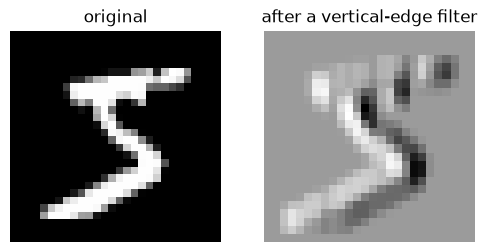

In [2]:
train_x, train_y, test_x, test_y = get_MNIST_data()

example_image = torch.tensor(train_x[0].reshape(1, 1, 28, 28), dtype=torch.float32)

vertical_edge_filter = torch.tensor(
    [[[-1.0, 0.0, 1.0], [-1.0, 0.0, 1.0], [-1.0, 0.0, 1.0]]]
).unsqueeze(0)

filtered = F.conv2d(example_image, vertical_edge_filter)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(example_image[0, 0].numpy(), cmap="Greys_r")
axes[0].set_title("original")
axes[0].axis("off")
axes[1].imshow(filtered[0, 0].detach().numpy(), cmap="Greys_r")
axes[1].set_title("after a vertical-edge filter")
axes[1].axis("off")
plt.show()

The same $3\times3$ filter was applied at every position of the image with a single
sliding-window operation; the output highlights vertical edges wherever they occur,
regardless of where in the image they are.

## 5-6. A small CNN, with tensor dimensions

```text
image (1x28x28)
    |
    v
Conv2d(1 -> 8, 3x3)   -> (8, 26, 26)
ReLU
MaxPool2d(2x2)        -> (8, 13, 13)
    |
    v
Conv2d(8 -> 16, 3x3)  -> (16, 11, 11)
ReLU
MaxPool2d(2x2)        -> (16, 5, 5)
    |
    v
flatten               -> (400,)
    |
    v
Linear(400 -> 10)     -> 10 digit scores
```

Pooling (`MaxPool2d`) reduces the spatial resolution after each convolution, keeping
only the strongest response in each small region. This both reduces computation and
makes the representation somewhat robust to small shifts in exactly where a pattern
occurs.

In [3]:
cnn_model = build_cnn_model(num_classes=10)
print(cnn_model)

n_params_cnn = sum(p.numel() for p in cnn_model.parameters())
print(f"total trainable parameters (CNN): {n_params_cnn:,}")

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten()
  (7): Linear(in_features=400, out_features=10, bias=True)
)
total trainable parameters (CNN): 5,258


In [4]:
fc_model_for_count = build_fully_connected_model(input_dim=784, hidden_dim=128, num_classes=10)
n_params_fc = sum(p.numel() for p in fc_model_for_count.parameters())
print(f"total trainable parameters (fully connected): {n_params_fc:,}")
print(f"total trainable parameters (CNN):              {n_params_cnn:,}")

total trainable parameters (fully connected): 101,770
total trainable parameters (CNN):              5,258


Despite having two convolutional layers, the CNN has far fewer parameters than the
fully connected network. This is exactly parameter sharing at work: instead of a
separate weight for every (pixel, hidden-unit) pair, the CNN reuses the same small set
of filter weights across every spatial position.

## 7. Train and validate the CNN

Images need to be reshaped into their original $1\times28\times28$ form (the
classical/fully-connected notebooks used the flattened $784$-d vectors).

In [5]:
train_x_img = np.reshape(train_x, (train_x.shape[0], 1, 28, 28))
test_x_img = np.reshape(test_x, (test_x.shape[0], 1, 28, 28))

dev_split_index = int(9 * len(train_x_img) / 10)
permutation = np.random.permutation(len(train_x_img))
train_x_img, train_y_shuf = train_x_img[permutation], train_y[permutation]

X_dev, y_dev = train_x_img[dev_split_index:], train_y_shuf[dev_split_index:]
X_train, y_train = train_x_img[:dev_split_index], train_y_shuf[:dev_split_index]

batch_size = 32
cnn_train_batches = batchify_data(X_train, y_train, batch_size)
cnn_dev_batches = batchify_data(X_dev, y_dev, batch_size)
cnn_test_batches = batchify_data(test_x_img, test_y, batch_size)

cnn_history = train_model(
    cnn_train_batches,
    cnn_dev_batches,
    cnn_model,
    lr=0.1,
    momentum=0.9,
    nesterov=True,
    n_epochs=10,
)

Epoch  1 | train loss 0.2111 acc 0.9377 | val loss 0.1651 acc 0.9473
Epoch  2 | train loss 0.1575 acc 0.9581 | val loss 0.1792 acc 0.9486
Epoch  3 | train loss 0.1575 acc 0.9575 | val loss 0.1364 acc 0.9643
Epoch  4 | train loss 0.1486 acc 0.9586 | val loss 0.1344 acc 0.9603
Epoch  5 | train loss 0.1447 acc 0.9606 | val loss 0.1433 acc 0.9599
Epoch  6 | train loss 0.1469 acc 0.9594 | val loss 0.1609 acc 0.9571
Epoch  7 | train loss 0.1406 acc 0.9627 | val loss 0.1461 acc 0.9568
Epoch  8 | train loss 0.1578 acc 0.9573 | val loss 0.1415 acc 0.9603
Epoch  9 | train loss 0.1602 acc 0.9573 | val loss 0.2515 acc 0.9280
Epoch 10 | train loss 0.2373 acc 0.9345 | val loss 0.1577 acc 0.9528


In [6]:
cnn_model.eval()
with torch.no_grad():
    cnn_test_loss, cnn_test_acc = run_epoch(cnn_test_batches, cnn_model, None)
print(f"CNN test loss: {cnn_test_loss:.4f}   CNN test accuracy: {cnn_test_acc:.4f}")

CNN test loss: 0.1413   CNN test accuracy: 0.9575


## 8. Compare the CNN with the MLP

To keep the comparison controlled, we retrain the same fully connected architecture
as Notebook 04 here, using the same number of epochs, batch size, and optimizer
settings as the CNN above, and evaluate both on the same test batches.

In [7]:
fc_model = build_fully_connected_model(input_dim=784, hidden_dim=128, num_classes=10)
fc_train_batches = batchify_data(train_x[permutation][:dev_split_index], train_y_shuf[:dev_split_index], batch_size)
fc_dev_batches = batchify_data(train_x[permutation][dev_split_index:], train_y_shuf[dev_split_index:], batch_size)
fc_test_batches = batchify_data(test_x, test_y, batch_size)

fc_history = train_model(
    fc_train_batches,
    fc_dev_batches,
    fc_model,
    lr=0.1,
    momentum=0.9,
    n_epochs=10,
    verbose=False,
)

fc_model.eval()
with torch.no_grad():
    fc_test_loss, fc_test_acc = run_epoch(fc_test_batches, fc_model, None)

print(f"Fully connected | test loss: {fc_test_loss:.4f}  test accuracy: {fc_test_acc:.4f}")
print(f"CNN             | test loss: {cnn_test_loss:.4f}  test accuracy: {cnn_test_acc:.4f}")

Fully connected | test loss: 0.2506  test accuracy: 0.9599
CNN             | test loss: 0.1413  test accuracy: 0.9575


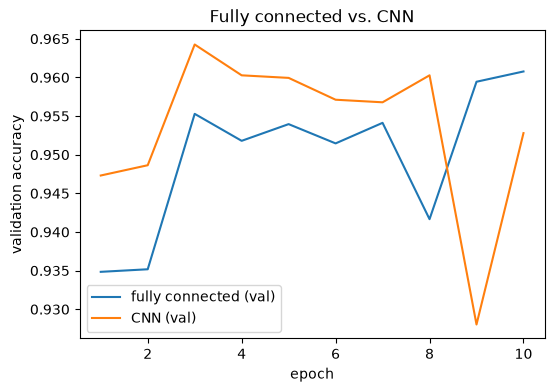

In [8]:
epochs = range(1, len(cnn_history["val_acc"]) + 1)
plt.figure(figsize=(6, 4))
plt.plot(epochs, fc_history["val_acc"], label="fully connected (val)")
plt.plot(epochs, cnn_history["val_acc"], label="CNN (val)")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Fully connected vs. CNN")
plt.legend()
plt.show()

A higher test accuracy for the CNN, by itself, does not *explain* why the CNN is
better; the accuracy numbers above are a starting point for the explanation, not a
substitute for it. The architectural reasons were established in sections 2-6 above:
local receptive fields and parameter sharing give the CNN an inductive bias suited to
image data, while the fully connected network must learn any spatial invariances from
data alone (or not at all, given a limited training set).

## 9. Inspect predictions and errors

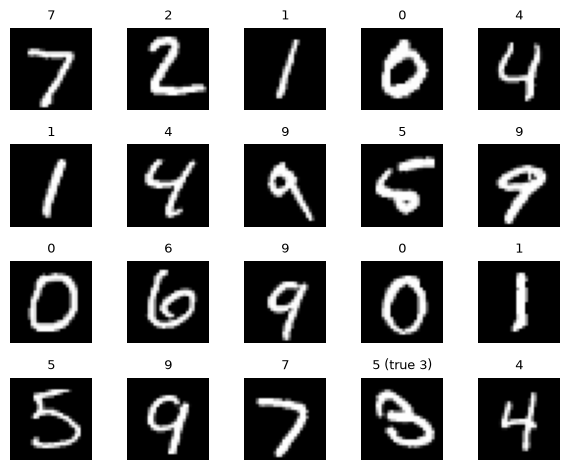

In [9]:
cnn_model.eval()
with torch.no_grad():
    sample_x = torch.tensor(test_x_img[:32], dtype=torch.float32)
    sample_y = test_y[:32]
    logits = cnn_model(sample_x)
    preds = torch.argmax(logits, dim=1).numpy()

labels = [f"{p}" + ("" if p == t else f" (true {t})") for p, t in zip(preds, sample_y)]
plot_images(test_x[:20], labels=labels[:20])

## Study questions

1. Why are convolution filters reused across the image?
2. What is gained by preserving spatial structure?
3. Why does parameter sharing reduce the number of parameters?
4. Why can a CNN recognize a pattern at different image locations?